In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from PIL import Image
import glob
import shutil

In [3]:
#data exploration
csv_path=os.listdir("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA")
count=0
totalcount=0
for paths in csv_path:
    totalcount+=1
    if paths.endswith('.jpg'):
        act_path=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths)
        #dat=pd.read_csv(act_path)
        # pd.set_option('display.max_rows', None)
        # pd.set_option('display.max_columns', None)
        # print(dat)
        imgpth=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths.replace(".jpg",".csv"))
        if not os.path.isfile(imgpth):
            count+=1
            print(paths)
print("img with no csv=",count)
            
        


1665-M-014Y1(1).jpg
img with no csv= 1


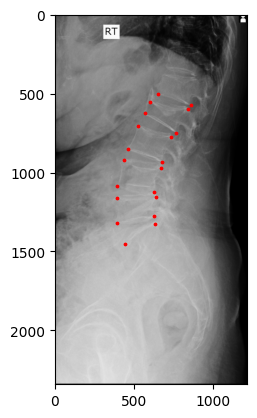

   685.9785   381.5689  902.6589   413.2783  0
0  650.0413   501.0074  863.5508   570.7679  0
1  603.5342   554.9133  844.5252   595.0784  0
2  568.6540   624.6738  767.3658   746.2263  0
3  527.4319   703.9471  735.6565   772.6507  0
4  461.8993   851.9240  676.4658   933.3113  0
5  435.4748   921.6846  671.1808   973.4764  0
6  395.3097  1083.4020  625.7308  1122.5100  0
7  391.0818  1160.5620  642.6425  1156.3340  0
8  395.3097  1322.2790  629.9587  1274.7150  0
9  446.0446  1451.2300  633.1296  1323.3360  0


In [4]:
#data exploration on images
imagedir='/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA'
csvdir=imagedir
count =0
for fname in os.listdir(imagedir):
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        csvname=name+'.csv'
        csvpth=os.path.join(csvdir,csvname)
        info=pd.read_csv(csvpth)

        fig,ax=plt.subplots()
        ax.imshow(img)
        ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
        ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        print(info)
        count+=1
        if count>0:
            break

In [5]:
#data cleaning
csv_path=os.listdir("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA")
dst="/kaggle/working/clean_data/"
csvdst = "/kaggle/working/clean_data/csv"
imgdst="/kaggle/working/clean_data/img"
os.makedirs(dst, exist_ok=True)
os.makedirs(csvdst, exist_ok=True)
os.makedirs(imgdst, exist_ok=True)
count=0
totalcount=0
for paths in csv_path:
    
    if paths.endswith('.csv'):
        totalcount+=1
        act_path=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths)
        #dat=pd.read_csv(act_path)
        # pd.set_option('display.max_rows', None)
        # pd.set_option('display.max_columns', None)
        # print(dat)
        imgpth=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths.replace(".csv",".jpg"))
        if os.path.isfile(imgpth):
            shutil.copy(act_path, csvdst)
            shutil.copy(imgpth, imgdst)
        else:
            print(paths,'skipped')
print('done')
            
        


1674-F-050Y1(1).csv skipped
1669-M-048Y1(1).csv skipped
1667-F-065Y1(1).csv skipped
done


In [ ]:
#data exploration on images after cleaning
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/working/clean_data/csv"
count =0
for fname in os.listdir(imagedir):
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        csvname=name+'.csv'
        csvpth=os.path.join(csvdir,csvname)
        info=pd.read_csv(csvpth)

        fig,ax=plt.subplots()
        ax.imshow(img)
        ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
        ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break


In [ ]:
#data on excel
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"

count =0
info=pd.read_excel(csvdir,sheet_name='Pos_LA',index_col='filename')
for fname in os.listdir(imagedir):
    
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        fig,ax=plt.subplots()
        ax.imshow(img)
        if name in info.index:
            row_data = info.loc[name]
        #use this:
        ax.scatter(row_data.iloc[3],row_data.iloc[4],c='red',s=3)
        #avoid this:
        ax.scatter(info.loc[name][5],info.loc[name][6],c='red',s=3)
        
        #ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break

In [ ]:
#data on excel according to diagnosis
imagedir='/kaggle/working/clean_data/img'
xldir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"
csvdir="/kaggle/working/clean_data/csv"
count1,count2,count3,count4=0,0,0,0
diaginfo=pd.read_excel(xldir,sheet_name='diagnosis',index_col='filename')
print(diaginfo.columns)
for fname in os.listdir(imagedir):
    
    
    if fname.endswith('.jpg'):
        name=os.path.splitext(fname)[0]
        if name in diaginfo.index:
            current_diagnosis = diaginfo.loc[name, 'diagnosis_number']
            
                
            if current_diagnosis == 3 and count3 == 0:
                print("Anterolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count3 += 1
                
            elif current_diagnosis == 4 and count4 == 0:
                print("Retrolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count4 += 1
            
            
            if count3 > 0 and count4 > 0:
                break
print("note: no left or right Laterolisthesis as dataset is dealing with only sagittal view")

In [37]:
#data preperation

from pandas import DataFrame
xldir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"
diaginfo=pd.read_excel(xldir,sheet_name='diagnosis')
csvinfo=pd.read_excel(xldir,sheet_name='Pos_LA')
xldst = "/kaggle/working/clean_data/excel"
os.makedirs(xldst, exist_ok=True)

diaginfo['diagnosis_no'] = diaginfo['diagnosis_number'].apply(lambda x: x if x in [3, 4] else 0)
diaginfo['gender'] = diaginfo['gender'].apply(lambda x: 0 if x == 'M' else 1)
diag_subset = diaginfo[['filename', 'diagnosis_no','gender']]
df = pd.merge(csvinfo, diag_subset, on='filename', how='left')
df['diagnosis_no'] = df['diagnosis_no'].fillna(0).astype(int)

output_path = os.path.join(xldst, 'test.xlsx') 
df.to_excel(output_path, sheet_name='sheet1', index=False)

print('merged diagnosis and points positions successfully')
        

merged diagnosis and points positions successfully


In [40]:
def predict_acc_to_leaves(no_of_leaves,train_X, val_X, train_y, val_y):
    rf_model = RandomForestRegressor(max_leaf_nodes=no_of_leaves,random_state=1)
    rf_model.fit(train_X, train_y)
    rf_val_predictions = rf_model.predict(val_X)
    rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)
    return rf_val_mae

In [42]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


xldst = "/kaggle/working/clean_data/excel/test.xlsx"
spine_data = pd.read_excel(xldst,sheet_name='sheet1', index_col='filename')
y = spine_data.diagnosis_no
# print(spine_data.columns)




# Select columns corresponding to features, and preview the data
X_before = spine_data[['gender', 'age', 'type', 'L1a_1c', 'L1a_1r', 'L1a_2c', 'L1a_2r',
       'L1b_1c', 'L1b_1r', 'L1b_2c', 'L1b_2r', 'L2a_1c', 'L2a_1r', 'L2a_2c',
       'L2a_2r', 'L2b_1c', 'L2b_1r', 'L2b_2c', 'L2b_2r', 'L3a_1c', 'L3a_1r',
       'L3a_2c', 'L3a_2r', 'L3b_1c', 'L3b_1r', 'L3b_2c', 'L3b_2r', 'L4a_1c',
       'L4a_1r', 'L4a_2c', 'L4a_2r', 'L4b_1c', 'L4b_1r', 'L4b_2c', 'L4b_2r',
       'L5a_1c', 'L5a_1r', 'L5a_2c', 'L5a_2r', 'L5b_1c', 'L5b_1r', 'L5b_2c',
       'L5b_2r', 'S1a_1c', 'S1a_1r', 'S1a_2c', 'S1a_2r']]
X=pd.get_dummies(X_before, columns=[ 'type'], drop_first=True)

# Split into validation and training data
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

# Define a random forest model
# rf_model = RandomForestRegressor(random_state=1)
# rf_model.fit(train_X, train_y)
# rf_val_predictions = rf_model.predict(val_X)
# rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)

no_of_leaves=[5,10,50,100,500,1000,100000]
best=999999999999999
no=0
for n in no_of_leaves:
    x=predict_acc_to_leaves(n,train_X, val_X, train_y, val_y)
    if x<best:
        best=x
        no=n

print("Validation MAE for Random Forest Model:",best,"no of leaves:",no)

KeyError: "['gender'] not in index"